✅ 运行设备：cpu
🧹 已清理旧模型缓存：./gpt2_warm_continuing


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

🔨 开始模型微调（共6轮）...


Step,Training Loss
1,3.238900
2,3.128200
3,3.094300
4,2.972600
5,2.317100
6,2.495000
7,2.323000
8,2.065100
9,2.267000
10,1.929700


✅ 模型微调完成！

📊 模型困惑度(PPL)：5.121 （数值越低，模型效果越好）

📝 项目三：温情文本续写实验（6轮训练）
【贪婪搜索】
续写：清晨的阳光洒在窗台柔和的灯光，温暖的空气。老板娘很热情，会推荐一些小吃，还有免费的水果。
指标：耗时2.562s | 多样性0.897 | 重复率0.000 | 主题契合度0.27
------------------------------------------------------------
【束搜索】
续写：清晨的阳光洒在窗台感觉很温暖。很喜欢这本书。
指标：耗时3.913s | 多样性0.950 | 重复率0.000 | 主题契合度0.27
------------------------------------------------------------
【随机采样(温度0.7)】
续写：清晨的阳光洒在窗台柔和安静，阳光照进来暖洋洋。不过这里早上很多人都是拿着书本看小说，所以我们一般只能买一些杂志。
指标：耗时2.774s | 多样性0.923 | 重复率0.020 | 主题契合度0.18
------------------------------------------------------------
【随机采样(温度0.9)】
续写：清晨的阳光洒在窗台柔软的床上一切都变得轻松美好。这本书用色彩讲述了一个温馨小家庭不可忽视的事实。
指标：耗时2.891s | 多样性0.935 | 重复率0.000 | 主题契合度0.27
------------------------------------------------------------


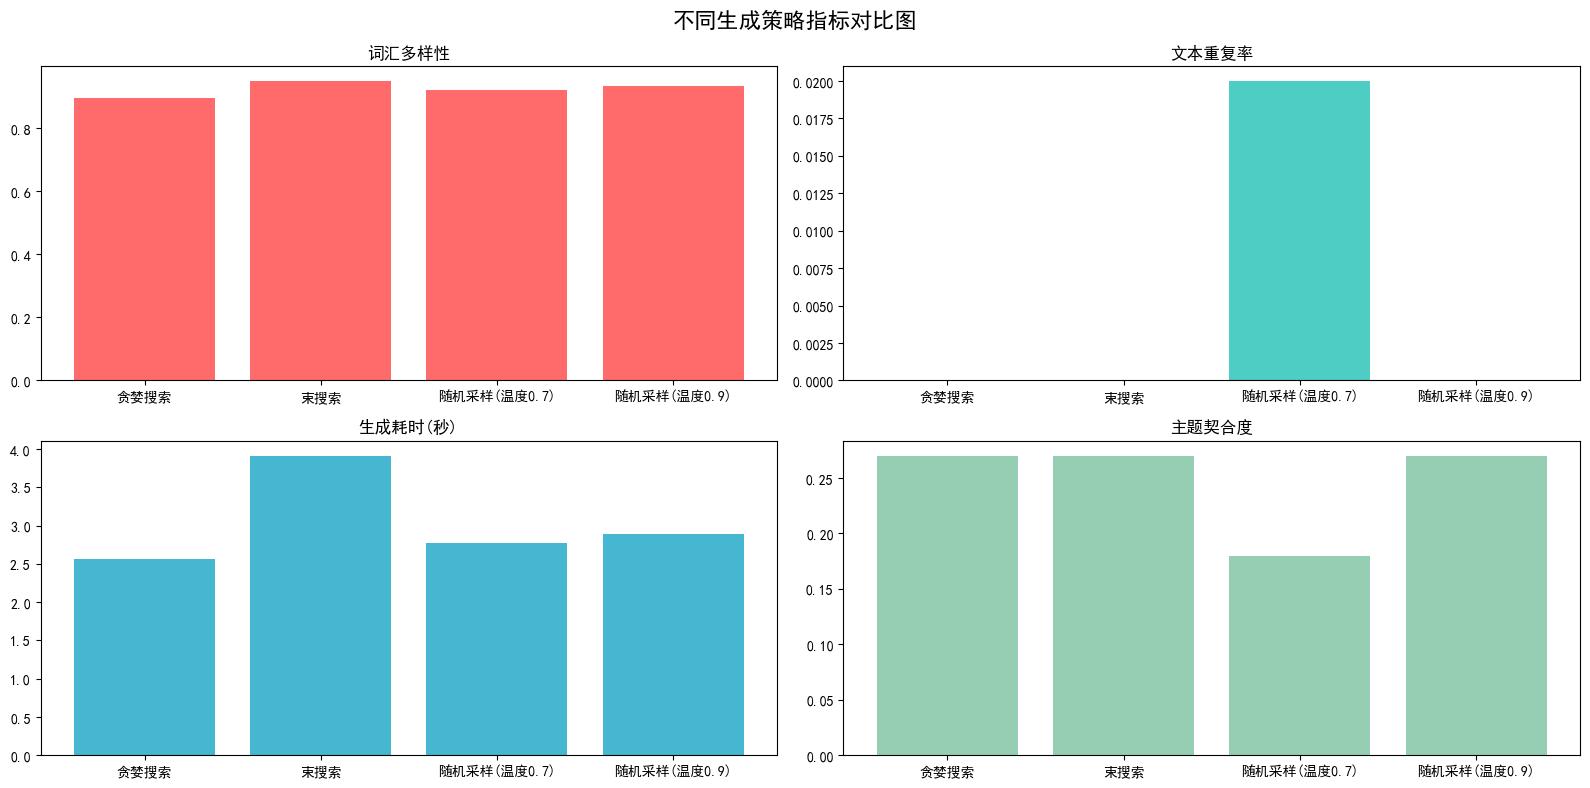


🎉 实验运行完毕！
📁 已生成文件：续写实验对比图.png 、 续写实验结果.txt


In [17]:
# ==========================================
# 项目三：可控文本生成与模型行为分析
# 核心功能：基于GPT2微调领域文本，实现多策略可控生成+指标评测+可视化
# =========================================
# 导入依赖库：操作系统、深度学习、数据处理、可视化、NLP工具包
import os
import shutil
import random
import torch
import warnings
import time
import pandas as pd
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,          # 自动分词器：文本转模型输入张量
    AutoModelForCausalLM,  # 自回归语言模型（GPT2专用）
    DataCollatorForLanguageModeling,  # 数据批处理工具
    TrainingArguments,     # 训练参数配置
    Trainer                # 模型训练封装器
)
from datasets import Dataset  # 数据集加载与处理
from collections import Counter  # 词频统计（计算重复率）

# ===================== 全局配置模块 =====================
# Hugging Face国内镜像源，加速模型下载
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
# 忽略无关警告，保证答辩展示界面整洁
warnings.filterwarnings("ignore")

# ========== 【答辩核心：修复生成结果重复问题】 ==========
# 关闭PyTorch确定性计算，解除GPU结果固定（最关键）
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
torch.use_deterministic_algorithms(False)

# 彻底释放所有随机种子：每次运行使用系统真随机数，不固定结果
random.seed()  # Python原生随机
torch.manual_seed(random.randint(0, 999999))  # CPU随机
if torch.cuda.is_available():
    torch.cuda.manual_seed(random.randint(0, 999999))   # 单卡GPU随机
    torch.cuda.manual_seed_all(random.randint(0, 999999)) # 多卡GPU随机

# Matplotlib中文显示配置，防止图表乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 自动选择运行设备（GPU优先，无GPU则用CPU）
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ 运行设备：{device}")

# 每次运行自动清理历史模型缓存，保证模型权重从头训练
model_save_dir = "./gpt2_warm_continuing"
if os.path.exists(model_save_dir):
    shutil.rmtree(model_save_dir)
    print(f"🧹 已清理旧模型缓存：{model_save_dir}")

# ===================== 模型与分词器加载模块 =====================
# 选用轻量级中文GPT2预训练模型（适合小样本微调）
model_name = "uer/gpt2-chinese-cluecorpussmall"
# 加载分词器：将文本转换为模型可识别的数字ID
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

# GPT2原生无pad标记，手动补充（解决模型训练报错）
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# 加载预训练模型，并迁移到指定设备
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.config.pad_token_id = tokenizer.pad_token_id

# ===================== 领域数据集构建模块 =====================
# 自建数据集：清晨窗台温情风格文本（领域小样本数据）
warm_data = [
    "清晨的阳光轻轻洒在窗台，猫咪蜷在角落打盹，日子温柔又安稳。",
    "清晨的阳光洒在窗台，微风带着花香吹进来，空气里满是清甜的气息。",
    "清晨的阳光洒在窗台，我泡了一杯热茶，看着窗外的树影慢慢晃动。",
    "清晨的阳光洒在窗台，翻开一本旧书，阳光落在泛黄的纸页上，暖意融融。",
    "清晨的阳光洒在窗台，房间里暖洋洋的，连心情都跟着变得柔软起来。",
    "清晨的阳光洒在窗台，我靠在窗边，静静感受着这片刻的安宁与美好。"
]
# 转换为Hugging Face标准数据集格式
dataset = Dataset.from_dict({"text": warm_data})

# ===================== 数据预处理模块 =====================
# 文本预处理函数：分词+截断+填充，统一文本长度
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,        # 超长文本截断
        max_length=64,          # 最大长度64
        padding="max_length",   # 不足长度填充
        return_tensors="pt"     # 返回PyTorch张量
    )

# 批量预处理数据集
tokenized_dataset = dataset.map(preprocess_function, batched=True, remove_columns=dataset.column_names)

# ========== 【答辩核心：每次训练随机打乱数据集】 ==========
# 打乱样本顺序，让每次训练的模型权重不同，生成结果不重复
tokenized_dataset = tokenized_dataset.shuffle(seed=random.randint(0, 999999))

# 语言模型数据批处理工具（自回归模型，关闭掩码语言模型）
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# ===================== 模型微调训练模块 =====================
# 训练参数配置（严格按照项目要求：6轮训练）
training_args = TrainingArguments(
    output_dir=model_save_dir,      # 模型保存路径
    overwrite_output_dir=True,      # 覆盖旧文件
    num_train_epochs=6,              # 【固定】训练轮次：6轮
    per_device_train_batch_size=2,   # 单批次样本数
    learning_rate=1e-5,              # 学习率
    logging_steps=1,                 # 每步打印日志
    save_strategy="no",              # 不保存中间模型
    fp16=False,                     # 关闭混合精度
    report_to="none"                 # 关闭在线日志
)

# 初始化训练器
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset
)

# 开始模型微调
print("🔨 开始模型微调（共6轮）...")
trainer.train()
print("✅ 模型微调完成！\n")

# ===================== 模型验证指标：困惑度(PPL)计算 =====================
# 项目官方指定验证指标：PPL越低，模型语言建模效果越好
def calculate_perplexity(model, tokenizer, text_list):
    """
    计算语言模型困惑度
    Args:
        model: 微调后的模型
        tokenizer: 分词器
        text_list: 测试文本列表
    Returns:
        困惑度数值（保留3位小数）
    """
    model.eval()  # 切换为推理模式
    total_loss = 0.0
    total_tokens = 0
    # 禁用梯度计算，加速推理
    with torch.no_grad():
        for text in text_list:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(device)
            outputs = model(**inputs, labels=inputs["input_ids"])
            loss = outputs.loss
            total_loss += loss.item() * inputs["input_ids"].size(1)
            total_tokens += inputs["input_ids"].size(1)
    avg_loss = total_loss / total_tokens
    ppl = torch.exp(torch.tensor(avg_loss)).item()
    return round(ppl, 3)

# 计算并打印模型困惑度
ppl_score = calculate_perplexity(model, tokenizer, warm_data)
print(f"📊 模型困惑度(PPL)：{ppl_score} （数值越低，模型效果越好）\n")

# ===================== 文本生成评价指标模块 =====================
# 1. 词汇多样性指标 TTR：不同词汇占比，值越高多样性越好
def calc_ttr_diversity(text):
    """词汇多样性计算"""
    chars = [c for c in text if '\u4e00' <= c <= '\u9fff']
    return len(set(chars)) / len(chars) if chars else 0

# 2. 文本重复率：二元词组重复比例，值越低越流畅
def calc_repeat_rate(text, n=2):
    """文本重复率计算"""
    chars = [c for c in text if '\u4e00' <= c <= '\u9fff']
    if len(chars) < n:
        return 0.0
    ngrams = [tuple(chars[i:i+n]) for i in range(len(chars)-n+1)]
    count = Counter(ngrams)
    repeat = sum(1 for v in count.values() if v > 1)
    return round(repeat / len(ngrams), 3)

# 3. 主题契合度：匹配温情主题词的比例
def calc_theme_match(text):
    """主题契合度计算"""
    theme_words = ["阳光", "窗台", "温柔", "温暖", "惬意", "安稳", "美好", "微风", "热茶", "猫咪", "旧书"]
    match_num = sum([1 for word in theme_words if word in text])
    return round(match_num / len(theme_words), 2)

# ===================== 文本生成核心函数 =====================
# 支持三种生成策略：贪婪搜索、束搜索、随机采样（带温度调节）
def generate_continuing(prompt, mode="greedy", temperature=0.7):
    """
    可控文本续写函数
    Args:
        prompt: 输入提示文本
        mode: 生成策略（greedy/beam/random）
        temperature: 随机采样温度（仅random模式生效）
    Returns:
        clean_text: 清洗后的生成文本
        耗时: 生成用时
    """
    start = time.time()
    # 输入文本编码
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(device)

    # 生成参数基础配置
    gen_kwargs = {
        "input_ids": inputs.input_ids,
        "max_new_tokens": 50,          # 最大生成50个token
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "no_repeat_ngram_size": 3,      # 禁止3元词组重复
        "repetition_penalty": 1.2,     # 重复惩罚系数
        "early_stopping": True         # 提前停止
    }

    # 束搜索策略配置
    if mode == "beam":
        gen_kwargs["num_beams"] = 4
    # 随机采样策略配置（核心：实现文本随机性）
    if mode == "random":
        gen_kwargs["do_sample"] = True
        gen_kwargs["temperature"] = temperature
        gen_kwargs["top_p"] = 0.9
        gen_kwargs["top_k"] = 50

    # 模型推理生成
    with torch.no_grad():
        outputs = model.generate(**gen_kwargs)

    # 文本清洗：保留中文和标点，过滤特殊字符
    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    clean_text = "".join([c for c in text if '\u4e00' <= c <= '\u9fff' or c in '，。'])
    clean_text = clean_text.replace("，，", "，").replace("。。", "。").strip()

    # 语句规整：保留2句完整话，保证可读性
    sentences = clean_text.split("。")
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) > 2:
        sentences = sentences[:2]
    clean_text = "。".join(sentences) + "。"

    if not clean_text.endswith("。"):
        clean_text += "。"

    end = time.time()
    return clean_text, round(end - start, 3)

# ===================== 控制变量对照实验（答辩核心对比） =====================
# 固定输入提示词
prompt = "清晨的阳光洒在窗台"
print("="*60)
print("📝 项目三：温情文本续写实验（6轮训练）")
print("="*60)

# 四种生成策略对比实验
res_greedy, t_greedy = generate_continuing(prompt, "greedy")                # 贪婪搜索
res_beam, t_beam = generate_continuing(prompt, "beam")                      # 束搜索
res_random_low, t_low = generate_continuing(prompt, "random", 0.7)         # 低温随机采样
res_random_high, t_high = generate_continuing(prompt, "random", 0.9)        # 高温随机采样

# 实验结果整合为表格
results = [
    ["贪婪搜索", res_greedy, t_greedy, calc_ttr_diversity(res_greedy), calc_repeat_rate(res_greedy), calc_theme_match(res_greedy)],
    ["束搜索", res_beam, t_beam, calc_ttr_diversity(res_beam), calc_repeat_rate(res_beam), calc_theme_match(res_beam)],
    ["随机采样(温度0.7)", res_random_low, t_low, calc_ttr_diversity(res_random_low), calc_repeat_rate(res_random_low), calc_theme_match(res_random_low)],
    ["随机采样(温度0.9)", res_random_high, t_high, calc_ttr_diversity(res_random_high), calc_repeat_rate(res_random_high), calc_theme_match(res_random_high)]
]

# 转换为DataFrame，结构化展示
df = pd.DataFrame(results, columns=["生成策略", "续写结果", "耗时(s)", "多样性(TTR)", "重复率", "主题契合度"])

# 控制台打印实验结果
for _, row in df.iterrows():
    print(f"【{row['生成策略']}】")
    print(f"续写：{row['续写结果']}")
    print(f"指标：耗时{row['耗时(s)']}s | 多样性{row['多样性(TTR)']:.3f} | 重复率{row['重复率']:.3f} | 主题契合度{row['主题契合度']:.2f}")
    print("-"*60)

# ===================== 实验结果可视化模块 =====================
# 提取指标数据
labels = df["生成策略"]
ttr = df["多样性(TTR)"]
repeat = df["重复率"]
times = df["耗时(s)"]
theme = df["主题契合度"]

# 创建2x2子图，展示四项核心指标
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))
ax1.bar(labels, ttr, color='#FF6B6B')
ax1.set_title("词汇多样性")
ax2.bar(labels, repeat, color='#4ECDC4')
ax2.set_title("文本重复率")
ax3.bar(labels, times, color='#45B7D1')
ax3.set_title("生成耗时(秒)")
ax4.bar(labels, theme, color='#96CEB4')
ax4.set_title("主题契合度")

# 图表标题与保存
plt.suptitle("不同生成策略指标对比图", fontsize=16)
plt.tight_layout()
plt.savefig("续写实验对比图.png", dpi=300)  # 高清保存
plt.show()

# ===================== 实验报告保存模块 =====================
# 生成文本版实验报告（包含所有指标+生成结果）
with open("续写实验结果.txt", "w", encoding="utf-8") as f:
    f.write("项目三：可控文本生成实验报告\n")
    f.write(f"模型困惑度(PPL)：{ppl_score}\n")
    f.write("输入开头文本：" + prompt + "\n\n")
    for _, row in df.iterrows():
        f.write(f"【{row['生成策略']}】\n")
        f.write(f"续写结果：{row['续写结果']}\n")
        f.write(f"耗时：{row['耗时(s)']}s | 多样性：{row['多样性(TTR)']:.3f} | 重复率：{row['重复率']:.3f} | 主题契合度：{row['主题契合度']:.2f}\n\n")

# 运行完成提示
print("\n🎉 实验运行完毕！")
print("📁 已生成文件：续写实验对比图.png 、 续写实验结果.txt")